# Get the Data

 *Your task is to predict median house values in Californian districts, given a number of features from these districts.*

## Download the Data

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing = pd.read_csv(url)

## View the first 5 rows of the data

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Get a quick description of the data

In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## Check categories in a text column

In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## View mathematical statistics for numerical columns

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Plot a histogram (data distribution) for all numerical columns

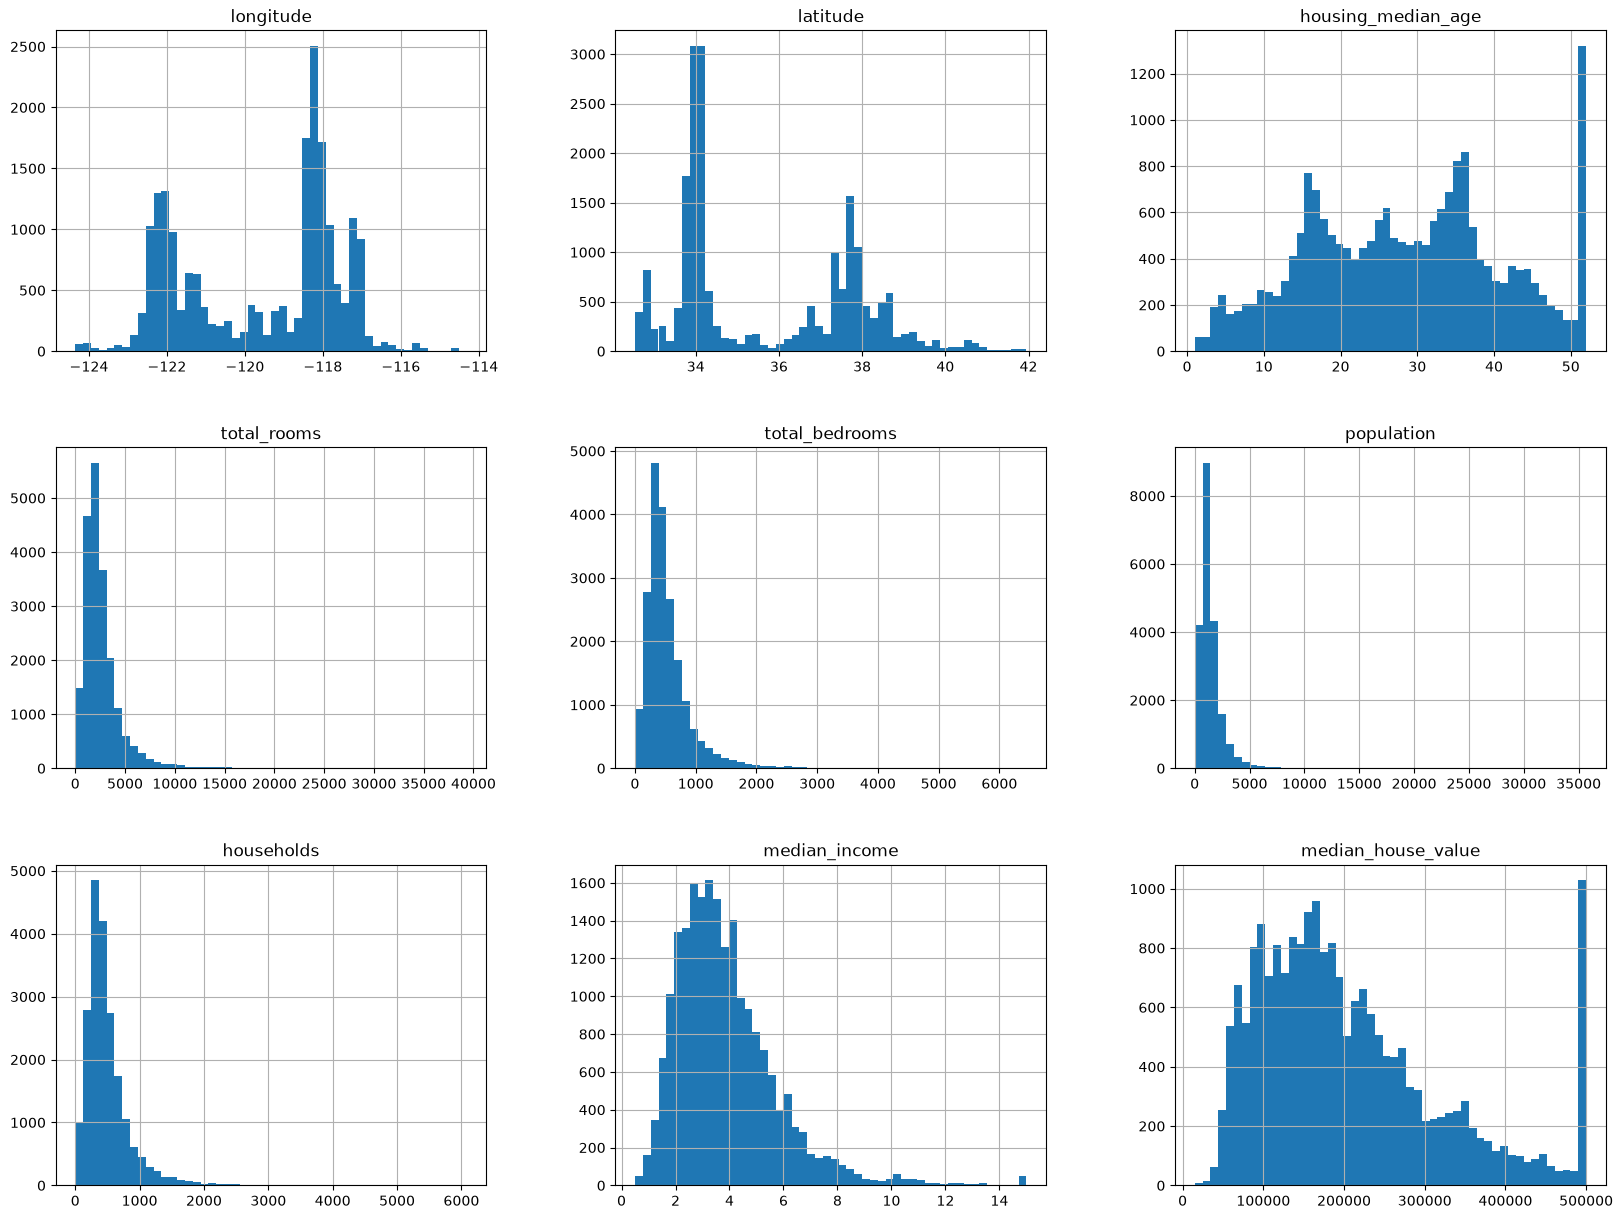

In [6]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

## Write a manual function to split 20% of the data as a test set

In [8]:
import numpy as np

def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * (test_ratio))
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [14]:
train_set, test_set = split_train_test(housing, 0.2)

In [10]:
print(len(test_set), len(train_set), len(train_set)+len(test_set))

4128 16512 20640


## Write the number of data points in the test set.

In [11]:
len(test_set)

4128

## Set a random seed to keep the results consistent across multiple runs

In [12]:
np.random.seed(42)

In [15]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


## Split data into train and test sets using Scikit-Learn's built-in function

In [17]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size = 0.2, random_state = 42)

In [18]:
len(train_set), len(test_set)

(16512, 4128)

## Check the number of missing values in a specific column

In [19]:
housing["total_bedrooms"].isnull().sum()

np.int64(207)

## Convert a continuous column (like median_income) into a categorical column

In [22]:
housing["income_cat"] = pd.cut(housing["median_income"],
                                bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
                                labels = [1, 2, 3, 4, 5])

In [24]:
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

## Plot a bar chart for the new categories

<Axes: xlabel='income_cat'>

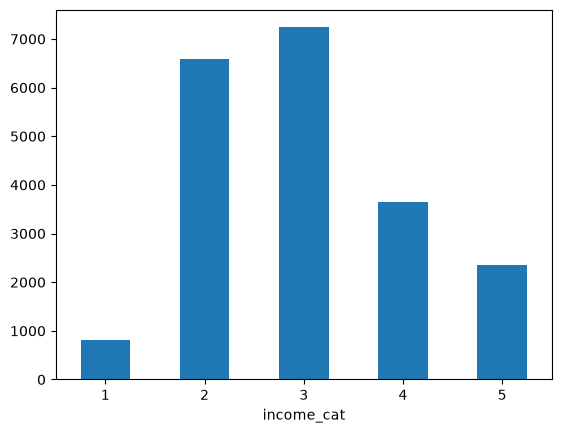

In [26]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0)

## Split data into train and test sets while maintaining the proportion of income categories (Stratified Sampling)

In [30]:
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(
    housing,
    test_size = 0.2,
    stratify= housing["income_cat"],
    random_state= 42
)

## Drop the extra column (income category) from the data to return it to its original state

In [31]:
strat_train_set = strat_train_set.drop("income_cat", axis=1)
strat_test_set = strat_test_set.drop("income_cat", axis=1)

In [33]:
strat_train_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

# Discover and Visualize the Data to Gain Insights

## Create an independent copy of the training data for exploration and plotting

In [34]:
housing = strat_train_set.copy()

## Plot a scatter plot (Geographical representation of districts based on longitude and latitude)

<Axes: xlabel='longitude', ylabel='latitude'>

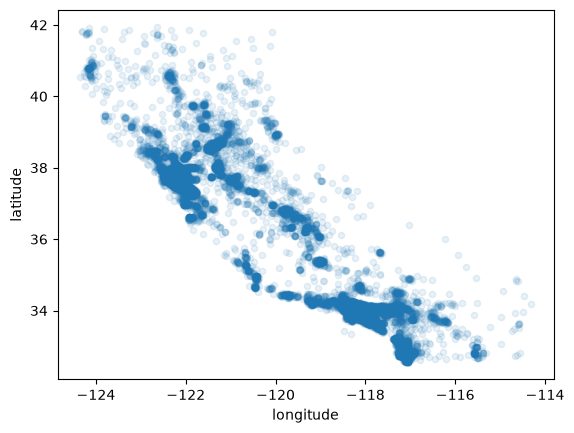

In [40]:
housing.plot(
    kind = "scatter",
    x = "longitude",
    y = "latitude",
    alpha=0.1
)

## Plot an advanced geographical map (Show population size with circle radius and house prices with color)

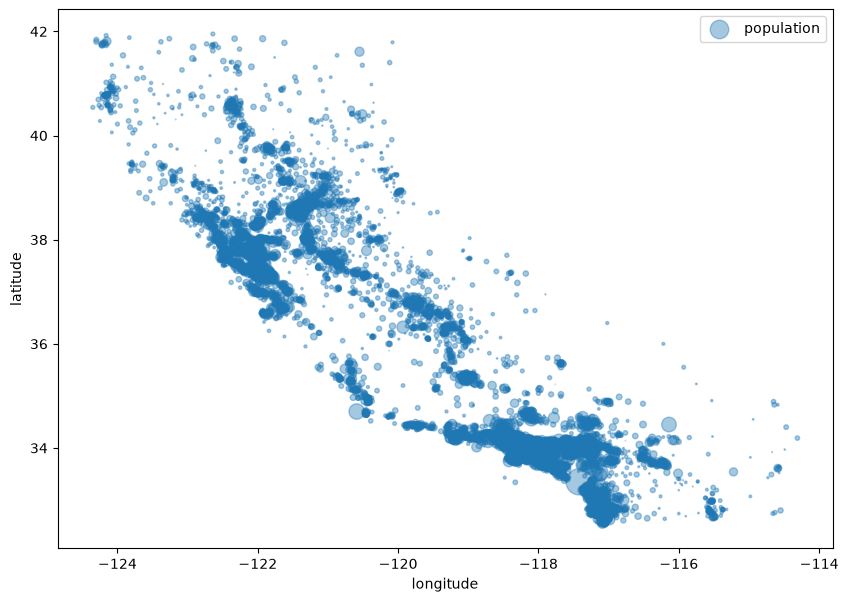

In [41]:
housing.plot(
    kind="scatter", 
    x="longitude", 
    y="latitude", 
    alpha=0.4,
    s=housing["population"]/100, 
    label="population", 
    figsize=(10,7)
)
plt.legend()

## Plot an advanced geographical map (Show population size with circle radius and house prices with color)

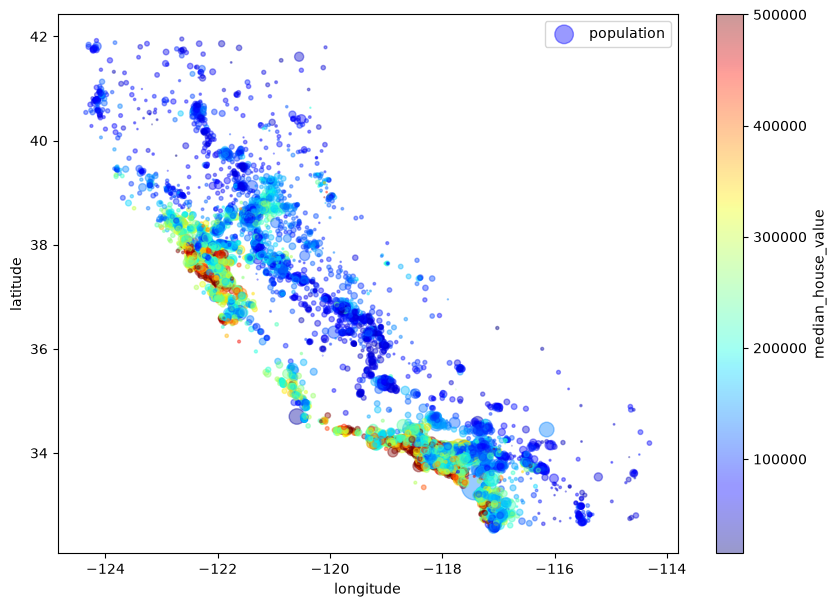

In [42]:
housing.plot(
    kind="scatter", 
    x="longitude", 
    y="latitude", 
    alpha=0.4,
    s=housing["population"]/100, 
    label="population", 
    figsize=(10,7),
    c="median_house_value", 
    cmap=plt.get_cmap("jet"), 
    colorbar=True
)
plt.legend()